# FX Carry Data Introduction

This notebook introduces the Bloomberg data universe used for the FX carry research project.

## Research Map

FX carry backtests need spot and forward data first. Spot gives the currency return, while forward points or outright forwards encode the carry earned from holding high-rate currencies against low-rate currencies. Bid and ask fields are important because gross carry strategies can look attractive before realistic transaction costs, especially in EM currencies and stressed markets.

FX options add forward-looking signals. ATM volatility measures expected currency volatility, risk reversals proxy skew and crash-risk pricing, and butterflies proxy smile convexity or tail-risk compensation. These are not required to compute plain carry returns, but they are useful for conditioning carry exposure or studying when carry is more fragile.

Global risk indicators such as VIX, MOVE, DXY, JPM FX volatility indices, equity indices, commodities, and government yields help identify regimes. Carry tends to perform differently in calm risk-on periods than in dollar squeezes, volatility spikes, commodity shocks, or rate selloffs.

Interest-rate and macro data are best treated as explanatory or robustness variables here. They can validate forward-implied carry, help explain cross-country return differences, and support regime analysis, but the primary return source should come from spot and forward data rather than standalone policy or money-market rates.


In [1]:
from pathlib import Path
import ast
import json
import math
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "src" / "bloomberg_data.py").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing src/bloomberg_data.py and data/.")


ROOT = find_project_root()
SOURCE_PATH = ROOT / "src" / "bloomberg_data.py"
DATA_DIR = ROOT / "data" / "raw"

print(f"Project root: {ROOT}")
print(f"Bloomberg source: {SOURCE_PATH}")
print(f"Data folder: {DATA_DIR}")


Project root: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo
Bloomberg source: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo/src/bloomberg_data.py
Data folder: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo/data/raw


## Requested Bloomberg Universe

The next cell reconstructs the requested universe directly from `src/bloomberg_data.py`. It executes only the ticker-definition blocks and the `GROUPS` dictionary, not the Bloomberg download code.


In [2]:
def unique_keep_order(items):
    seen = set()
    out = []
    for x in items:
        if x and x not in seen:
            out.append(x)
            seen.add(x)
    return out


def extract_assignment_block(source_text, assignment_name):
    match = re.search(rf"(?m)^{re.escape(assignment_name)}\s*=\s*{{", source_text)
    if match is None:
        raise ValueError(f"Could not find top-level assignment for {assignment_name}")
    start = match.start()
    brace_start = source_text.index("{", start)
    depth = 0
    in_string = False
    quote = ""
    escaped = False
    for i in range(brace_start, len(source_text)):
        ch = source_text[i]
        if in_string:
            if escaped:
                escaped = False
            elif ch == "\\":
                escaped = True
            elif ch == quote:
                in_string = False
            continue
        if ch in ["'", '"']:
            in_string = True
            quote = ch
        elif ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return source_text[start:i + 1]
    raise ValueError(f"Could not extract {assignment_name} block")


def load_requested_universe_from_source(source_path):
    source = source_path.read_text()
    start_marker = "# ---------- G10 FX ----------"
    end_marker = "def load_manual_macro_tickers"
    universe_block = source[source.index(start_marker):source.index(end_marker)]
    groups_block = extract_assignment_block(source, "GROUPS")

    ns = {
        "PRICE_FIELDS": ["PX_LAST", "PX_BID", "PX_ASK"],
        "LAST_FIELD": ["PX_LAST"],
        "manual_macro_tickers": [],
        "unique_keep_order": unique_keep_order,
    }
    exec(universe_block, ns)
    exec(groups_block, ns)

    groups = {}
    for group, spec in ns["GROUPS"].items():
        tickers = unique_keep_order(spec.get("tickers", []))
        fields = unique_keep_order(spec.get("fields", []))
        if tickers:
            groups[group] = {"tickers": tickers, "fields": fields}
    return groups


GROUPS = load_requested_universe_from_source(SOURCE_PATH)

requested_overview = pd.DataFrame([
    {
        "group": group,
        "tickers_requested": len(spec["tickers"]),
        "requested_fields": ", ".join(spec["fields"]),
    }
    for group, spec in GROUPS.items()
]).sort_values("group")

display(requested_overview)


,group,tickers_requested,requested_fields
3,em_fx_options,325,"PX_LAST, PX_BID, PX_ASK"
1,em_fx_spot_forward,103,"PX_LAST, PX_BID, PX_ASK"
6,em_interest_rates,35,PX_LAST
11,em_onshore_rates,16,PX_LAST
12,em_risk,1,PX_LAST
8,fx_carry_benchmarks,3,PX_LAST
2,g10_fx_options,275,"PX_LAST, PX_BID, PX_ASK"
0,g10_fx_spot_forward,66,"PX_LAST, PX_BID, PX_ASK"
5,g10_interest_rates,83,PX_LAST
10,g10_rates_gaps,4,PX_LAST


## Data Group Roles

| Data group | Research role | What it represents | How it is used |
|---|---|---|---|
| `g10_fx_spot_forward` | Core carry data | G10 USD FX spot plus 1W, 1M, 3M, 6M, and 12M forwards | Main G10 carry returns, forward-implied carry, and transaction-cost adjustment from bid/ask |
| `em_fx_spot_forward` | Core carry data | EM USD FX spot, deliverable forwards, and NDF-style forward conventions | Main EM carry returns; CNH/CNY/INR conventions need extra care |
| `g10_fx_options` | Option-implied signal data | G10 ATM vols (`V`), 25-delta/10-delta risk reversals (`R`), and butterflies (`B`) across tenors | Volatility, skew, and crash-risk signals for timing or conditioning carry |
| `em_fx_options` | Option-implied signal data | EM ATM vols, risk reversals, and butterflies | EM volatility/skew controls; likely noisier and more liquidity-sensitive than G10 |
| `global_risk` | Risk-control data | VIX, MOVE, DXY, equity indices, JPM FX vol indices, commodities, and US yields | Regime filters for global risk appetite, dollar strength, volatility, commodity shocks, and rate regimes |
| `g10_interest_rates` | Explanatory / robustness data | G10 OIS, IBOR, and money-market proxies | Validate carry signals and explain rate differentials; not the primary return source |
| `em_interest_rates` | Explanatory / robustness data | EM policy, deposit, swap, and local money-market proxies | Robustness checks and local-rate explanations for EM carry |
| `macro_market_proxies` | Optional explanatory data | US macro/financial conditions, developed-market yields, and commodities | Broader macro controls and regime variables |
| `fx_carry_benchmarks` | Validation / benchmark data | External FX carry benchmark indices | Sanity-check self-constructed carry returns and information ratios |
| `usd_riskfree` | Robustness / cash-rate data | US 3M bill yield proxy | Excess-return conversion or cash benchmark checks |
| `g10_rates_gaps` | Supplemental rate data | DKK and HKD short-rate proxies | Fills gaps for optional G10 currencies |
| `em_onshore_rates` | Supplemental rate data | Onshore EM money-market proxies | CIP-basis checks and local-rate robustness for EM currencies |
| `em_risk` | Optional risk-control data | EM sovereign credit spread proxy | EM-specific stress/regime filter |

`manual_macro_tickers` is defined in the script as an optional hook. It is excluded from the table when no manual ticker file is present.


## Load Downloaded Data

The loader looks for `{group}_long.parquet` first and then `{group}_long.csv`. It records errors and keeps going if a file is missing or a parquet engine is unavailable.


In [3]:
def empty_long_frame():
    return pd.DataFrame(columns=["date", "ticker", "field", "value"])


def read_long_group(group, data_dir=DATA_DIR):
    parquet_path = data_dir / f"{group}_long.parquet"
    csv_path = data_dir / f"{group}_long.csv"
    status = {
        "group": group,
        "path": None,
        "loaded": False,
        "rows": 0,
        "error": "",
    }

    for path, reader in [(parquet_path, pd.read_parquet), (csv_path, pd.read_csv)]:
        if not path.exists():
            continue
        try:
            df = reader(path)
            for col in ["date", "ticker", "field", "value"]:
                if col not in df.columns:
                    df[col] = np.nan
            df = df[["date", "ticker", "field", "value"]].copy()
            df["date"] = pd.to_datetime(df["date"], errors="coerce")
            df["ticker"] = df["ticker"].astype("string")
            df["field"] = df["field"].astype("string")
            df["value"] = pd.to_numeric(df["value"], errors="coerce")
            status.update({"path": str(path.relative_to(ROOT)), "loaded": True, "rows": len(df)})
            return df, status
        except Exception as exc:
            status.update({"path": str(path.relative_to(ROOT)), "error": repr(exc)})

    if status["path"] is None:
        status["error"] = "No *_long.parquet or *_long.csv file found"
    return empty_long_frame(), status


all_file_groups = sorted({p.name.replace("_long.parquet", "").replace("_long.csv", "") for p in DATA_DIR.glob("*_long.*")})
all_groups = unique_keep_order(list(GROUPS) + [g for g in all_file_groups if g not in GROUPS])

data_by_group = {}
load_status = []
for group in all_groups:
    df, status = read_long_group(group)
    data_by_group[group] = df
    load_status.append(status)

load_status = pd.DataFrame(load_status)
display(load_status.sort_values("group"))


,group,path,loaded,rows,error
3,em_fx_options,data/raw/em_fx_options_long.parquet,True,4847571,
1,em_fx_spot_forward,data/raw/em_fx_spot_forward_long.parquet,True,1393179,
6,em_interest_rates,data/raw/em_interest_rates_long.parquet,True,134365,
11,em_onshore_rates,data/raw/em_onshore_rates_long.parquet,True,87564,
12,em_risk,data/raw/em_risk_long.parquet,True,5091,
8,fx_carry_benchmarks,data/raw/fx_carry_benchmarks_long.parquet,True,15273,
2,g10_fx_options,data/raw/g10_fx_options_long.parquet,True,4170477,
0,g10_fx_spot_forward,data/raw/g10_fx_spot_forward_long.parquet,True,1007085,
5,g10_interest_rates,data/raw/g10_interest_rates_long.parquet,True,365973,
10,g10_rates_gaps,data/raw/g10_rates_gaps_long.parquet,True,20364,


## Overview by Data Group

This table compares requested Bloomberg tickers with the tickers actually present in the downloaded long files. The observation count is the number of non-missing ticker-field-date values.


In [4]:
def summarize_group(group, df):
    requested = GROUPS.get(group, {}).get("tickers", [])
    requested_set = set(requested)
    available = sorted(df["ticker"].dropna().astype(str).unique()) if not df.empty else []
    available_set = set(available)
    fields = sorted(df["field"].dropna().astype(str).unique()) if not df.empty else []
    dates = df.loc[df["date"].notna(), "date"] if not df.empty else pd.Series(dtype="datetime64[ns]")
    non_missing = df.loc[df["value"].notna()] if not df.empty else df

    missing = [t for t in requested if t not in available_set]
    extra = [t for t in available if requested_set and t not in requested_set]

    return {
        "group": group,
        "tickers_requested": len(requested),
        "tickers_available": len(available),
        "fields_available": ", ".join(fields) if fields else "",
        "earliest_date": dates.min().date().isoformat() if len(dates) else "",
        "latest_date": dates.max().date().isoformat() if len(dates) else "",
        "observations": int(len(non_missing)),
        "missing_tickers": len(missing),
        "extra_tickers": len(extra),
        "missing_or_suspicious_tickers": ", ".join(missing[:10]) + (" ..." if len(missing) > 10 else ""),
    }


group_overview = pd.DataFrame([summarize_group(g, data_by_group[g]) for g in all_groups])
role_map = {
    "g10_fx_spot_forward": "core carry data",
    "em_fx_spot_forward": "core carry data",
    "g10_fx_options": "option-implied signal data",
    "em_fx_options": "option-implied signal data",
    "global_risk": "risk-control data",
    "g10_interest_rates": "explanatory / robustness data",
    "em_interest_rates": "explanatory / robustness data",
    "macro_market_proxies": "optional explanatory data",
    "fx_carry_benchmarks": "benchmark / validation data",
    "usd_riskfree": "cash-rate robustness data",
    "g10_rates_gaps": "supplemental rate data",
    "em_onshore_rates": "supplemental rate data",
    "em_risk": "optional EM risk-control data",
}
group_overview.insert(1, "research_role", group_overview["group"].map(role_map).fillna("other"))

display(group_overview.sort_values("group"))


,group,research_role,tickers_requested,tickers_available,fields_available,earliest_date,latest_date,observations,missing_tickers,extra_tickers,missing_or_suspicious_tickers
3,em_fx_options,option-implied signal data,325,325,"PX_ASK, PX_BID, PX_LAST",2007-01-01,2026-06-30,4837355,0,0,
1,em_fx_spot_forward,core carry data,103,95,"PX_ASK, PX_BID, PX_LAST",2007-01-01,2026-06-30,1391517,8,0,"CNY1M Curncy, CNY3M Curncy, CNY6M Curncy, CNY1..."
6,em_interest_rates,explanatory / robustness data,35,34,PX_LAST,2007-01-01,2026-06-30,134365,1,0,CLSWA Curncy
11,em_onshore_rates,supplemental rate data,16,16,PX_LAST,2007-01-01,2026-07-06,87564,5,5,"MIBOR1M Index, MIFOR3M Index, SORA Index, HICN..."
12,em_risk,optional EM risk-control data,1,1,PX_LAST,2007-01-01,2026-07-06,5091,0,0,
8,fx_carry_benchmarks,benchmark / validation data,3,3,PX_LAST,2007-01-01,2026-07-06,15273,0,0,
2,g10_fx_options,option-implied signal data,275,275,"PX_ASK, PX_BID, PX_LAST",2007-01-01,2026-06-30,4168866,0,0,
0,g10_fx_spot_forward,core carry data,66,66,"PX_ASK, PX_BID, PX_LAST",2007-01-01,2026-06-30,1007049,0,0,
5,g10_interest_rates,explanatory / robustness data,83,81,PX_LAST,2007-01-01,2026-06-30,365973,2,0,"NIBOR12M Index, STIB12M Index"
10,g10_rates_gaps,supplemental rate data,4,4,PX_LAST,2007-01-01,2026-07-06,20364,0,0,


## Core Spot and Forward Blocks

Spot and forwards are the main backtest inputs. A clean carry return needs matched spot and forward observations at the chosen horizon, with careful handling of quote direction. Bid/ask data allow the same strategy to be evaluated net of realistic entry and exit costs.

For G10, the core sample should focus on the liquid currencies in `G10_CORE` and treat DKK/HKD as optional because pegs and liquidity conventions can make their carry behavior less comparable. For EM, NDF and special forward conventions should be checked currency by currency. CNH can be useful, but it should be reported both included and excluded because offshore China data can change the interpretation of an EM carry sample.


In [5]:
core_groups = ["g10_fx_spot_forward", "em_fx_spot_forward"]
display(group_overview[group_overview["group"].isin(core_groups)].sort_values("group"))


,group,research_role,tickers_requested,tickers_available,fields_available,earliest_date,latest_date,observations,missing_tickers,extra_tickers,missing_or_suspicious_tickers
1,em_fx_spot_forward,core carry data,103,95,"PX_ASK, PX_BID, PX_LAST",2007-01-01,2026-06-30,1391517,8,0,"CNY1M Curncy, CNY3M Curncy, CNY6M Curncy, CNY1..."
0,g10_fx_spot_forward,core carry data,66,66,"PX_ASK, PX_BID, PX_LAST",2007-01-01,2026-06-30,1007049,0,0,


## FX Option Blocks

The option tickers encode implied-volatility surfaces. `V` tickers are ATM volatility, `25R` and `10R` are risk reversals, and `25B` and `10B` are butterflies. In carry research, these are useful for testing whether high-carry currencies are exposed to volatility spikes, downside skew, or crash-risk premia.

These data should be treated as signal or conditioning variables rather than the base return source. Option coverage can also be more sensitive to market conventions, holidays, stale quotes, and entitlement limits.


In [6]:
option_groups = ["g10_fx_options", "em_fx_options"]
display(group_overview[group_overview["group"].isin(option_groups)].sort_values("group"))

option_type_patterns = {
    "ATM vol (V)": "V",
    "25D risk reversal (25R)": "25R",
    "25D butterfly (25B)": "25B",
    "10D risk reversal (10R)": "10R",
    "10D butterfly (10B)": "10B",
}
option_rows = []
for group in option_groups:
    tickers = GROUPS.get(group, {}).get("tickers", [])
    available = set(data_by_group[group]["ticker"].dropna().astype(str).unique()) if group in data_by_group else set()
    for label, pattern in option_type_patterns.items():
        req = [t for t in tickers if pattern in t]
        avail = [t for t in req if t in available]
        option_rows.append({"group": group, "option_block": label, "requested": len(req), "available": len(avail)})

display(pd.DataFrame(option_rows))


,group,research_role,tickers_requested,tickers_available,fields_available,earliest_date,latest_date,observations,missing_tickers,extra_tickers,missing_or_suspicious_tickers
3,em_fx_options,option-implied signal data,325,325,"PX_ASK, PX_BID, PX_LAST",2007-01-01,2026-06-30,4837355,0,0,
2,g10_fx_options,option-implied signal data,275,275,"PX_ASK, PX_BID, PX_LAST",2007-01-01,2026-06-30,4168866,0,0,


,group,option_block,requested,available
0,g10_fx_options,ATM vol (V),55,55
1,g10_fx_options,25D risk reversal (25R),55,55
2,g10_fx_options,25D butterfly (25B),55,55
3,g10_fx_options,10D risk reversal (10R),55,55
4,g10_fx_options,10D butterfly (10B),55,55
5,em_fx_options,ATM vol (V),65,65
6,em_fx_options,25D risk reversal (25R),65,65
7,em_fx_options,25D butterfly (25B),65,65
8,em_fx_options,10D risk reversal (10R),65,65
9,em_fx_options,10D butterfly (10B),65,65


## Regime, Macro, and Rate Blocks

`global_risk` is the main regime-control block. VIX and MOVE capture equity and rate volatility, DXY captures broad USD pressure, JPM FX vol indices capture currency-market stress, equity indices capture risk appetite, commodities capture terms-of-trade shocks, and US yields capture rate-regime shifts.

The interest-rate and macro blocks are useful, but they should not replace forwards as the primary carry-return source. Their best role is explanatory: validating forward-implied carry, testing robustness, and explaining why carry works or fails in different environments.


In [7]:
regime_rate_groups = [
    "global_risk", "g10_interest_rates", "em_interest_rates", "macro_market_proxies",
    "fx_carry_benchmarks", "usd_riskfree", "g10_rates_gaps", "em_onshore_rates", "em_risk",
]
display(group_overview[group_overview["group"].isin(regime_rate_groups)].sort_values("group"))


,group,research_role,tickers_requested,tickers_available,fields_available,earliest_date,latest_date,observations,missing_tickers,extra_tickers,missing_or_suspicious_tickers
6,em_interest_rates,explanatory / robustness data,35,34,PX_LAST,2007-01-01,2026-06-30,134365,1,0,CLSWA Curncy
11,em_onshore_rates,supplemental rate data,16,16,PX_LAST,2007-01-01,2026-07-06,87564,5,5,"MIBOR1M Index, MIFOR3M Index, SORA Index, HICN..."
12,em_risk,optional EM risk-control data,1,1,PX_LAST,2007-01-01,2026-07-06,5091,0,0,
8,fx_carry_benchmarks,benchmark / validation data,3,3,PX_LAST,2007-01-01,2026-07-06,15273,0,0,
5,g10_interest_rates,explanatory / robustness data,83,81,PX_LAST,2007-01-01,2026-06-30,365973,2,0,"NIBOR12M Index, STIB12M Index"
10,g10_rates_gaps,supplemental rate data,4,4,PX_LAST,2007-01-01,2026-07-06,20364,0,0,
4,global_risk,risk-control data,19,19,PX_LAST,2007-01-01,2026-06-30,95156,0,0,
7,macro_market_proxies,optional explanatory data,24,24,PX_LAST,2007-01-01,2026-06-30,98582,0,0,
9,usd_riskfree,cash-rate robustness data,1,1,PX_LAST,2007-01-01,2026-07-06,5091,0,0,


## Data-Quality Checks

The checks below flag coverage gaps, missing tickers, duplicated tickers, stale end dates, very short histories, and tickers that should not be used in the main sample without a deliberate research choice.


In [8]:
def ticker_coverage(group, df):
    if df.empty:
        return pd.DataFrame(columns=["group", "ticker", "fields", "earliest_date", "latest_date", "observations", "unique_dates"])
    tmp = df.copy()
    tmp_non_missing = tmp[tmp["value"].notna()].copy()
    if tmp_non_missing.empty:
        tmp_non_missing = tmp
    cov = (tmp_non_missing
        .groupby("ticker", dropna=True)
        .agg(
            fields=("field", lambda x: ", ".join(sorted(set(map(str, x.dropna()))))),
            earliest_date=("date", "min"),
            latest_date=("date", "max"),
            observations=("value", "count"),
            unique_dates=("date", lambda x: x.dropna().nunique()),
        )
        .reset_index())
    cov.insert(0, "group", group)
    cov["earliest_date"] = cov["earliest_date"].dt.date.astype(str)
    cov["latest_date"] = cov["latest_date"].dt.date.astype(str)
    return cov

coverage_by_ticker = pd.concat([ticker_coverage(g, df) for g, df in data_by_group.items()], ignore_index=True)

# Missing requested tickers.
missing_rows = []
for group, spec in GROUPS.items():
    available = set(data_by_group.get(group, empty_long_frame())["ticker"].dropna().astype(str).unique())
    for ticker in spec["tickers"]:
        if ticker not in available:
            missing_rows.append({"group": group, "ticker": ticker})
missing_by_group = pd.DataFrame(missing_rows)
if missing_by_group.empty:
    missing_by_group = pd.DataFrame(columns=["group", "ticker"])

display(Markdown("### Date-range coverage by group"))
display(group_overview[["group", "earliest_date", "latest_date", "tickers_requested", "tickers_available", "observations"]].sort_values("group"))

display(Markdown("### Missing tickers by group"))
if missing_by_group.empty:
    display(Markdown("No requested tickers are missing from the loaded files."))
else:
    display(missing_by_group.sort_values(["group", "ticker"]))


### Date-range coverage by group

,group,earliest_date,latest_date,tickers_requested,tickers_available,observations
3,em_fx_options,2007-01-01,2026-06-30,325,325,4837355
1,em_fx_spot_forward,2007-01-01,2026-06-30,103,95,1391517
6,em_interest_rates,2007-01-01,2026-06-30,35,34,134365
11,em_onshore_rates,2007-01-01,2026-07-06,16,16,87564
12,em_risk,2007-01-01,2026-07-06,1,1,5091
8,fx_carry_benchmarks,2007-01-01,2026-07-06,3,3,15273
2,g10_fx_options,2007-01-01,2026-06-30,275,275,4168866
0,g10_fx_spot_forward,2007-01-01,2026-06-30,66,66,1007049
5,g10_interest_rates,2007-01-01,2026-06-30,83,81,365973
10,g10_rates_gaps,2007-01-01,2026-07-06,4,4,20364


### Missing tickers by group

,group,ticker
3,em_fx_spot_forward,CNY12M Curncy
0,em_fx_spot_forward,CNY1M Curncy
1,em_fx_spot_forward,CNY3M Curncy
2,em_fx_spot_forward,CNY6M Curncy
7,em_fx_spot_forward,INR12M Curncy
4,em_fx_spot_forward,INR1M Curncy
5,em_fx_spot_forward,INR3M Curncy
6,em_fx_spot_forward,INR6M Curncy
10,em_interest_rates,CLSWA Curncy
14,em_onshore_rates,HICNH01M Index


In [9]:
# Duplicated requested tickers within a group and duplicate ticker-date-field rows in the loaded data.
requested_duplicates = []
for group, spec in GROUPS.items():
    counts = Counter(spec["tickers"])
    requested_duplicates.extend({"group": group, "ticker": t, "requested_count": c} for t, c in counts.items() if c > 1)
requested_duplicates = pd.DataFrame(requested_duplicates)
if requested_duplicates.empty:
    requested_duplicates = pd.DataFrame(columns=["group", "ticker", "requested_count"])

data_duplicate_rows = []
for group, df in data_by_group.items():
    if df.empty:
        continue
    duplicate_count = int(df.duplicated(subset=["date", "ticker", "field"], keep=False).sum())
    if duplicate_count:
        data_duplicate_rows.append({"group": group, "duplicate_ticker_date_field_rows": duplicate_count})
data_duplicate_rows = pd.DataFrame(data_duplicate_rows)
if data_duplicate_rows.empty:
    data_duplicate_rows = pd.DataFrame(columns=["group", "duplicate_ticker_date_field_rows"])

# Cross-group duplicates can be intentional, but they are useful to know about.
all_requested = []
for group, spec in GROUPS.items():
    for ticker in spec["tickers"]:
        all_requested.append({"group": group, "ticker": ticker})
all_requested = pd.DataFrame(all_requested)
cross_group_duplicates = (all_requested.groupby("ticker")
    .agg(groups=("group", lambda x: ", ".join(sorted(set(x)))), group_count=("group", "nunique"))
    .reset_index())
cross_group_duplicates = cross_group_duplicates[cross_group_duplicates["group_count"] > 1].sort_values(["group_count", "ticker"], ascending=[False, True])

# Stale and short histories.
stale_rows = []
short_rows = []
for group, cov in coverage_by_ticker.groupby("group"):
    cov2 = cov.copy()
    cov2["latest_dt"] = pd.to_datetime(cov2["latest_date"], errors="coerce")
    group_latest = cov2["latest_dt"].max()
    if pd.notna(group_latest):
        stale = cov2[cov2["latest_dt"] < group_latest - pd.Timedelta(days=31)].copy()
        for _, row in stale.iterrows():
            stale_rows.append({"group": group, "ticker": row["ticker"], "latest_date": row["latest_date"], "group_latest_date": group_latest.date().isoformat()})
    median_dates = cov2["unique_dates"].median() if len(cov2) else np.nan
    threshold = max(252, 0.10 * median_dates) if pd.notna(median_dates) else 252
    short = cov2[cov2["unique_dates"] < threshold].copy()
    for _, row in short.iterrows():
        short_rows.append({"group": group, "ticker": row["ticker"], "unique_dates": int(row["unique_dates"]), "threshold": int(math.ceil(threshold))})

stale_end_dates = pd.DataFrame(stale_rows)
if stale_end_dates.empty:
    stale_end_dates = pd.DataFrame(columns=["group", "ticker", "latest_date", "group_latest_date"])
very_short_history = pd.DataFrame(short_rows)
if very_short_history.empty:
    very_short_history = pd.DataFrame(columns=["group", "ticker", "unique_dates", "threshold"])

do_not_use_main = pd.DataFrame([
    {"group": "g10_fx_spot_forward", "ticker_or_rule": "DKK/HKD", "reason": "Optional pegged or semi-pegged currencies; keep outside the main liquid G10 sample unless specifically studied."},
    {"group": "em_fx_spot_forward", "ticker_or_rule": "CNH", "reason": "Report EM carry both excluding and including CNH because offshore China data can change interpretation."},
    {"group": "em_fx_spot_forward", "ticker_or_rule": "CNY simple forwards", "reason": "Requested CNY simple forwards are missing; avoid using CNY in the main sample unless the correct convention is verified."},
    {"group": "em_fx_spot_forward", "ticker_or_rule": "INR simple forwards", "reason": "Requested INR simple forwards are missing; use verified NDF/special convention only after manual checks."},
    {"group": "em_fx_options", "ticker_or_rule": "USDCNY / USDCNH", "reason": "Useful for China-specific analysis, but should be separated in main EM option tests."},
    {"group": "*_interest_rates", "ticker_or_rule": "standalone rates", "reason": "Use as explanatory or robustness data, not as the primary carry-return source."},
])

display(Markdown("### Requested duplicate tickers within group"))
display(requested_duplicates)

display(Markdown("### Duplicate loaded ticker-date-field rows"))
display(data_duplicate_rows)

display(Markdown("### Tickers requested in more than one group, usually intentional"))
display(cross_group_duplicates.head(30))

display(Markdown("### Tickers with stale end dates"))
display(stale_end_dates.sort_values(["group", "latest_date", "ticker"]))

display(Markdown("### Tickers with very short history"))
display(very_short_history.sort_values(["group", "unique_dates", "ticker"]))

display(Markdown("### Tickers or rules to exclude from the main sample"))
display(do_not_use_main)


### Requested duplicate tickers within group

,group,ticker,requested_count


### Duplicate loaded ticker-date-field rows

,group,duplicate_ticker_date_field_rows


### Tickers requested in more than one group, usually intentional

...

,group,ticker,latest_date,group_latest_date
2,em_interest_rates,CLTN30DS Curncy,2010-05-14,2026-06-30
0,em_interest_rates,BCCDIO Curncy,2015-12-15,2026-06-30
1,em_interest_rates,BCSWAPD Curncy,2016-02-22,2026-06-30
3,em_interest_rates,IDBIRATE Index,2016-07-21,2026-06-30
8,em_interest_rates,PRBOPRB1 Index,2021-07-15,2026-06-30
9,em_interest_rates,PRBOPRB3 Index,2021-07-15,2026-06-30
10,em_interest_rates,PRBOPRBI Index,2021-07-15,2026-06-30
7,em_interest_rates,PPSWO1 Index,2023-06-30,2026-06-30
11,em_interest_rates,PREF1MO Index,2023-06-30,2026-06-30
12,em_interest_rates,PREF3MO Index,2023-06-30,2026-06-30


### Tickers with very short history

,group,ticker,unique_dates,threshold
0,em_interest_rates,IHSWOOA Curncy,396,467
3,macro_market_proxies,GDP CUR$ Index,77,507
1,macro_market_proxies,CPI YOY Index,232,507
2,macro_market_proxies,CPURNSA Index,232,507
4,macro_market_proxies,M2% YOY Index,233,507


### Tickers or rules to exclude from the main sample

,group,ticker_or_rule,reason
0,g10_fx_spot_forward,DKK/HKD,Optional pegged or semi-pegged currencies; kee...
1,em_fx_spot_forward,CNH,Report EM carry both excluding and including C...
2,em_fx_spot_forward,CNY simple forwards,Requested CNY simple forwards are missing; avo...
3,em_fx_spot_forward,INR simple forwards,Requested INR simple forwards are missing; use...
4,em_fx_options,USDCNY / USDCNH,"Useful for China-specific analysis, but should..."
5,*_interest_rates,standalone rates,"Use as explanatory or robustness data, not as ..."


## Compact Coverage Plot

A single date-range plot is enough for orientation. The tables above are the main audit record.


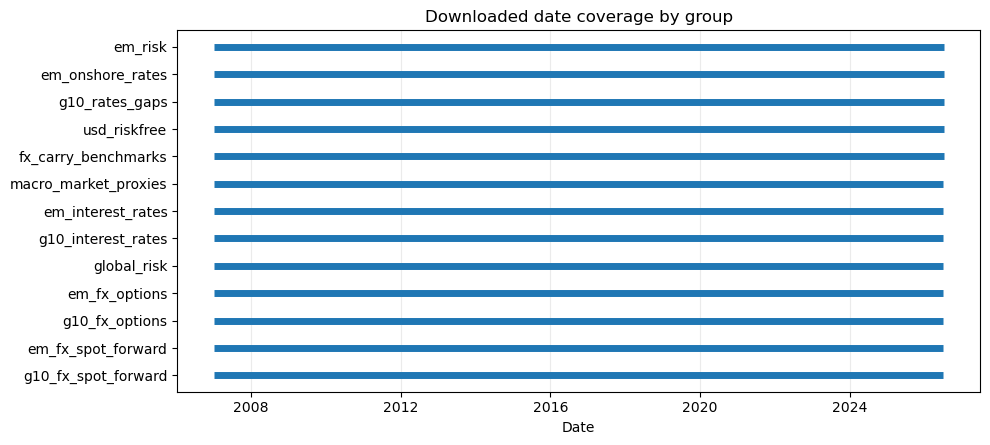

In [10]:
plot_df = group_overview.copy()
plot_df["start"] = pd.to_datetime(plot_df["earliest_date"], errors="coerce")
plot_df["end"] = pd.to_datetime(plot_df["latest_date"], errors="coerce")
plot_df = plot_df.dropna(subset=["start", "end"]).sort_values("start")

if plt is None or plot_df.empty:
    display(Markdown("Coverage plot skipped because matplotlib is unavailable or no date ranges were loaded."))
else:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
    for y, (_, row) in enumerate(plot_df.iterrows()):
        ax.hlines(y=y, xmin=row["start"], xmax=row["end"], linewidth=5)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df["group"])
    ax.set_title("Downloaded date coverage by group")
    ax.set_xlabel("Date")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()


## Recommended Clean Research Samples

These samples separate the core return construction from optional signals and robustness data. The goal is to make the main conclusions less sensitive to ticker-convention choices.


In [11]:
def available_count(group, tickers):
    available = set(data_by_group.get(group, empty_long_frame())["ticker"].dropna().astype(str).unique())
    return sum(t in available for t in tickers)

G10_CORE = ["AUD", "CAD", "CHF", "EUR", "GBP", "JPY", "NOK", "NZD", "SEK"]
EM_EX_CNH = ["MXN", "ZAR", "BRL", "KRW", "IDR", "MYR", "PHP", "CLP", "COP", "PEN", "SGD", "INR", "THB", "PLN", "HUF", "TRY", "ILS"]
EM_WITH_CNH = EM_EX_CNH + ["CNH"]

sample_rows = [
    {
        "sample": "G10 carry sample",
        "main_groups": "g10_fx_spot_forward",
        "currency_scope": ", ".join(G10_CORE),
        "recommended_use": "Main developed-market carry backtest using spot and forward data; use bid/ask for transaction costs.",
        "cautions": "Keep DKK and HKD optional because peg dynamics make them less comparable.",
    },
    {
        "sample": "EM carry sample excluding CNH",
        "main_groups": "em_fx_spot_forward",
        "currency_scope": ", ".join(EM_EX_CNH),
        "recommended_use": "Primary EM carry backtest after confirming each currency's forward/NDF convention.",
        "cautions": "Exclude CNY; verify INR special/NDF convention before inclusion.",
    },
    {
        "sample": "EM carry sample including CNH",
        "main_groups": "em_fx_spot_forward",
        "currency_scope": ", ".join(EM_WITH_CNH),
        "recommended_use": "Sensitivity sample showing whether offshore China exposure changes EM carry results.",
        "cautions": "Report separately from the ex-CNH sample.",
    },
    {
        "sample": "Option-enhanced carry sample",
        "main_groups": "g10_fx_spot_forward, em_fx_spot_forward, g10_fx_options, em_fx_options",
        "currency_scope": "Currencies with matched spot/forward and option coverage",
        "recommended_use": "Condition carry exposure on ATM vol, risk reversals, and butterflies.",
        "cautions": "Require aligned option tenors and lag signals to avoid look-ahead bias.",
    },
    {
        "sample": "Macro/rates-augmented sample",
        "main_groups": "core FX + global_risk + rates + macro_market_proxies",
        "currency_scope": "Core G10/EM samples with matched explanatory variables",
        "recommended_use": "Robustness, attribution, and regime-filter regressions.",
        "cautions": "Do not substitute standalone rates for forward-based carry returns in the main backtest.",
    },
]

recommended_samples = pd.DataFrame(sample_rows)
display(recommended_samples)


,sample,main_groups,currency_scope,recommended_use,cautions
0,G10 carry sample,g10_fx_spot_forward,"AUD, CAD, CHF, EUR, GBP, JPY, NOK, NZD, SEK",Main developed-market carry backtest using spo...,Keep DKK and HKD optional because peg dynamics...
1,EM carry sample excluding CNH,em_fx_spot_forward,"MXN, ZAR, BRL, KRW, IDR, MYR, PHP, CLP, COP, P...",Primary EM carry backtest after confirming eac...,Exclude CNY; verify INR special/NDF convention...
2,EM carry sample including CNH,em_fx_spot_forward,"MXN, ZAR, BRL, KRW, IDR, MYR, PHP, CLP, COP, P...",Sensitivity sample showing whether offshore Ch...,Report separately from the ex-CNH sample.
3,Option-enhanced carry sample,"g10_fx_spot_forward, em_fx_spot_forward, g10_f...",Currencies with matched spot/forward and optio...,"Condition carry exposure on ATM vol, risk reve...",Require aligned option tenors and lag signals ...
4,Macro/rates-augmented sample,core FX + global_risk + rates + macro_market_p...,Core G10/EM samples with matched explanatory v...,"Robustness, attribution, and regime-filter reg...",Do not substitute standalone rates for forward...


## Data Readiness Assessment

**Is the dataset ready for FX carry research?**  
Yes, the downloaded spot/forward blocks appear ready for a first FX carry research pass, provided the backtest code respects quote direction, uses the correct forward convention for each currency, and excludes or separately reports problematic currencies such as CNY/CNH and optional pegs.

**Reliable enough for the main backtest.**  
The strongest candidates are `g10_fx_spot_forward` and `em_fx_spot_forward`, with `PX_LAST`, `PX_BID`, and `PX_ASK` available for return construction and transaction-cost adjustment. `global_risk` is also suitable for broad regime filters.

**Optional or use carefully.**  
FX options are useful for volatility, skew, and crash-risk signals, but should be matched by tenor and checked for stale quotes. Interest-rate, macro, benchmark, onshore-rate, and EM-risk data are valuable for robustness and interpretation, not as the primary carry-return source.

**Fix or manually verify next.**  
Confirm missing CNY and INR forward conventions, verify failed or missing rate tickers, decide whether DKK/HKD and CNH belong in the reported main sample, and manually inspect any stale or very short ticker histories flagged above. If a Python environment cannot read parquet files, install `pyarrow` or open the notebook with an environment that already has parquet support.


In [12]:
readiness = {
    "loaded_groups": int(load_status["loaded"].sum()) if not load_status.empty else 0,
    "groups_with_missing_tickers": int(missing_by_group["group"].nunique()) if not missing_by_group.empty else 0,
    "missing_requested_tickers": int(len(missing_by_group)),
    "groups_with_stale_tickers": int(stale_end_dates["group"].nunique()) if not stale_end_dates.empty else 0,
    "very_short_history_tickers": int(len(very_short_history)),
}

display(pd.DataFrame([readiness]))


,loaded_groups,groups_with_missing_tickers,missing_requested_tickers,groups_with_stale_tickers,very_short_history_tickers
0,13,4,16,3,5
